In [19]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

In [20]:
# Generate sample data
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)

In [21]:
# Create and train model
model = KMeans(
    n_clusters=4,          # Number of clusters
    init='k-means++',      # Smart initialization
    n_init=10,             # Number of initializations
    max_iter=300,          # Maximum iterations
    random_state=42
)
model.fit(X)

KMeans(n_clusters=4, n_init=10, random_state=42)

In [22]:
# Get cluster assignments and centroids
labels = model.labels_
centroids = model.cluster_centers_

In [23]:
# Evaluate
print(f"Inertia (within-cluster sum of squares): {model.inertia_}")
print(f"Cluster Centers:\n{centroids}")

Inertia (within-cluster sum of squares): 203.89074684058335
Cluster Centers:
[[-2.60516878  8.99280115]
 [-6.85126211 -6.85031833]
 [ 4.68687447  2.01434593]
 [-8.83456141  7.24430734]]


In [24]:
# Predict cluster for new data
new_data = np.array([[0, 0], [4, 4]])
predictions = model.predict(new_data)
print(f"Predictions for new data: {predictions}")

Predictions for new data: [2 2]


In [25]:
# Elbow method to find optimal K
inertias = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

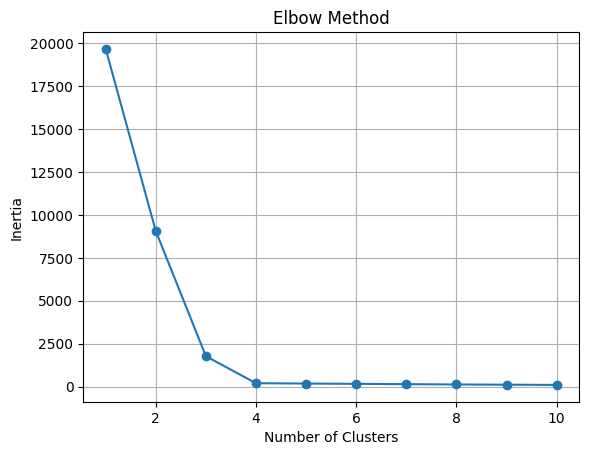

In [29]:
# Plot the Elbow
plt.plot(range(1, 11), inertias, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()